In [1]:
%load_ext autoreload
%autoreload 2
import scMPRAforge as scm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
import numpy as np



2025-12-11 15:51:28.606957: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-11 15:51:28.680708: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [2]:
# cluster.close()

In [2]:

#create dask cluster
from dask.distributed import Client, LocalCluster
from dask_jobqueue import SLURMCluster
# cluster=LocalCluster(n_workers=10)
# client = Client(cluster)

cluster=SLURMCluster(
    cores=4,#cores per slurm job
    memory="64G",#memory per slurm job
    processes=1,#dask workers per slurm job
    job_extra_directives=["-p day", 
        f"--job-name=simclust_worker",
        f"--time=4:00:00",
        f"--output=worker_%j.out"]
)
cluster.scale(jobs=6)
client = Client(cluster,
        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
        heartbeat_interval="20s"  # Worker heartbeat interval
    )




In [3]:
client.dashboard_link

'http://10.18.22.67:8787/status'

In [4]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="shendure_ortho_20260306"
precomp_name = 'shendure_ortho_20260306_precomp_test_opg'

import os
if os.path.isdir(path+"/"+precomp_name):
    print("[+]PreComp Model found. Loading...")
    primordial=scm.ortho.load(client,path,precomp_name)
    shendure=primordial.training_data
elif os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    shendure=primordial.training_data
    primordial.precompute_wald(client, cov_method="opg")
    primordial.save(path, precomp_name) 
# else:
#     print("[+] Model not found. Creating...")

#     #load data
#     data_root="/gpfs/gibbs/pi/reilly/tabula_data"
#     shendure=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_grouped.txt")
    
#     shendure.set_negative_controls(["minP","noP"])
#     shendure.set_reference_cell("Pluripotent")
#     shendure.ortho_filter()

#     primordial=scm.ortho()
#     primordial.criss_cross(client=client,
#                        dat=shendure)
#     primordial.extract_params(client)
#     primordial.save(path,name)

[+] Model found. Loading...


# Test wald and mwu

In [5]:
# by-cell-type: test many CREs in NeuroectodermBrain vs the 'reference' negative control
hs_ct = scm.make_by_celltype_hypotheses(
    comparison_cell_type="NeuroectodermBrain",
    counts=shendure,
    comparison_cres="all",          # or a list like ["CRE1","CRE2",...]
    reference_cre="reference",      # this is how you labeled minP/noP
    meta="emvar_screen"
)

# by-CRE: test CRE123 across all cell types vs the baseline cell type
hs_cre = scm.make_by_cre_hypotheses(
    comparison_cre="ubcP",
    counts=shendure,
    comparison_cell_types="all",    # or a list
    reference_cell_type="reference",   # will default to counts.reference_cell_type if set
    meta="cell_specificity"
)

# all CREs within each cell type, vs the 'reference' negative control
hs_all_ct = scm.make_all_by_celltype_hypotheses(
    counts=shendure,
    reference_cre="reference",
    meta="emvar_screen",
)

# all cell types for each CRE, vs the dataset’s baseline cell type
hs_all_cre = scm.make_all_by_cre_hypotheses(
    counts=shendure,
    reference_cell_type="reference",  # will be normalized to 'reference'
    meta="cell_specificity",
)




In [6]:
hs_all_ct.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta
0,Gata4_chr14_5742,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen
1,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen
2,pgk1P,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen
3,Foxa2_chr2_13840,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen
4,Map1b_chr13_9447,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen
...,...,...,...,...,...
1447,Lama1_chr17_7814,reference,reference,reference,emvar_screen
1448,Tgfbi_chr13_5735,reference,reference,reference,emvar_screen
1449,Igfbp4_chr11_16738,reference,reference,reference,emvar_screen
1450,Tgfbi_chr13_5701,reference,reference,reference,emvar_screen


In [7]:
hs_all_cre.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta
0,Bend5_chr4_8168,SurfaceEctoderm,Bend5_chr4_8168,reference,cell_specificity
1,Bend5_chr4_8168,NeuroectodermBrain,Bend5_chr4_8168,reference,cell_specificity
2,Bend5_chr4_8168,EpiblastPrimitiveStreak,Bend5_chr4_8168,reference,cell_specificity
3,Bend5_chr4_8168,ExEndodermParietal,Bend5_chr4_8168,reference,cell_specificity
4,Bend5_chr4_8170,NeuroectodermBrain,Bend5_chr4_8170,reference,cell_specificity
...,...,...,...,...,...
1241,ubcP,Mesoderm,ubcP,reference,cell_specificity
1242,ubcP,ExEndodermParietal,ubcP,reference,cell_specificity
1243,ubcP,Cardiomyocytes,ubcP,reference,cell_specificity
1244,ubcP,Haematoendothelial,ubcP,reference,cell_specificity


## Wald


In [8]:
runner = scm.HypothesisTester("wald")
wald_by_ct  = runner.run(hs_all_ct, primordial, client)
wald_by_cre = runner.run(hs_all_cre, primordial, client)

In [9]:
wald_ct_df = wald_by_ct.to_dataframe()
wald_cre_df = wald_by_cre.to_dataframe()

In [10]:
wald_ct_df

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p
0,Gata4_chr14_5742,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,11.844121,2.308257e-32,23.256896,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,7.115902e-32
1,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,-3.257119,1.125491e-03,0.354268,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,1.776319e-03
2,pgk1P,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,72.631512,2.225074e-308,980.591944,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,2.884649e-307
3,Foxa2_chr2_13840,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,4.152853,3.283563e-05,3.719022,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,5.563283e-05
4,Map1b_chr13_9447,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,31.558560,1.368294e-218,27.962383,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,1.351539e-217
...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Lama1_chr17_7814,reference,reference,reference,emvar_screen,22.911439,3.573406e-116,2.129951,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,2.117790e-115
1448,Tgfbi_chr13_5735,reference,reference,reference,emvar_screen,-7.800293,6.176374e-15,0.360091,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,1.388250e-14
1449,Igfbp4_chr11_16738,reference,reference,reference,emvar_screen,13.824114,1.823430e-43,2.099714,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,6.379809e-43
1450,Tgfbi_chr13_5701,reference,reference,reference,emvar_screen,-4.685736,2.789561e-06,0.297607,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,4.888404e-06


In [11]:
wald_ct_df[wald_ct_df.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p


In [12]:
wald_ct_df[wald_ct_df.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p


## Compare Wald to bootstrapping

In [13]:
counts_groupby_cre = shendure.data

counts_groupby_cre_agg = counts_groupby_cre.groupby(['cre_id', 'cell_type']).agg(
    Sum=('umis_mpra_bc', 'sum'), Size=('umis_mpra_bc','size'), Mean=('umis_mpra_bc', 'mean'), Mean_Norm=('normalized_umis_mpra_bc', 'mean')
)
counts_groupby_cre_agg = counts_groupby_cre_agg.reset_index()
counts_groupby_cre_agg

,cre_id,cell_type,Sum,Size,Mean,Mean_Norm
0,Bend5_chr4_8168,EpiblastPrimitiveStreak,7,257,0.027237,0.017582
1,Bend5_chr4_8168,ExEndodermParietal,10,295,0.033898,0.044408
2,Bend5_chr4_8168,NeuroectodermBrain,9,477,0.018868,0.043506
3,Bend5_chr4_8168,SurfaceEctoderm,7,379,0.018470,0.039675
4,Bend5_chr4_8168,reference,28,603,0.046434,0.040273
...,...,...,...,...,...,...
1457,ubcP,Mesoderm,39393,3361,11.720619,22.122065
1458,ubcP,NeuroectodermBrain,37230,3435,10.838428,18.712594
1459,ubcP,NeuroectodermRostral,8078,777,10.396396,30.621628
1460,ubcP,SurfaceEctoderm,32415,2271,14.273448,23.663330


In [14]:
wald_ct_df_merge = pd.merge(wald_ct_df, counts_groupby_cre_agg[['cre_id','cell_type','Mean','Mean_Norm']], left_on=['comparison_CRE', 'comparison_cell_type'], right_on = ["cre_id", "cell_type"], how='inner')

In [15]:
wald_ct_df_merge

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,cre_id,cell_type,Mean,Mean_Norm
0,Gata4_chr14_5742,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,11.844121,2.308257e-32,23.256896,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,7.115902e-32,Gata4_chr14_5742,Cardiomyocytes,1.018519,0.854951
1,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,-3.257119,1.125491e-03,0.354268,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,1.776319e-03,Lamc1_chr1_12152,Cardiomyocytes,0.015625,0.012398
2,pgk1P,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,72.631512,2.225074e-308,980.591944,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,2.884649e-307,pgk1P,Cardiomyocytes,44.027027,74.399625
3,Foxa2_chr2_13840,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,4.152853,3.283563e-05,3.719022,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,5.563283e-05,Foxa2_chr2_13840,Cardiomyocytes,0.164706,0.204896
4,Map1b_chr13_9447,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,31.558560,1.368294e-218,27.962383,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,1.351539e-217,Map1b_chr13_9447,Cardiomyocytes,1.230769,1.074173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Lama1_chr17_7814,reference,reference,reference,emvar_screen,22.911439,3.573406e-116,2.129951,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,2.117790e-115,Lama1_chr17_7814,reference,0.351588,0.212829
1448,Tgfbi_chr13_5735,reference,reference,reference,emvar_screen,-7.800293,6.176374e-15,0.360091,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,1.388250e-14,Tgfbi_chr13_5735,reference,0.059459,0.040890
1449,Igfbp4_chr11_16738,reference,reference,reference,emvar_screen,13.824114,1.823430e-43,2.099714,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,6.379809e-43,Igfbp4_chr11_16738,reference,0.346491,0.200838
1450,Tgfbi_chr13_5701,reference,reference,reference,emvar_screen,-4.685736,2.789561e-06,0.297607,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,4.888404e-06,Tgfbi_chr13_5701,reference,0.049133,0.042656


In [16]:
wald_ct_df_summary = wald_ct_df_merge.loc[
    wald_ct_df_merge.groupby("comparison_CRE")["Mean_Norm"].idxmax()
][["comparison_CRE", "test_statistic", "bh_p", "fold_change", "cell_type"]].rename(columns={
    "fold_change": "glm_max_activity_fold_change",
    "bh_p": "glm_activity_adj_p"
})

wald_ct_df_summary["glm_is_active"] = wald_ct_df_summary["glm_activity_adj_p"] < 0.05
wald_ct_df_summary

,comparison_CRE,test_statistic,glm_activity_adj_p,glm_max_activity_fold_change,cell_type,glm_is_active
378,Bend5_chr4_8168,1.079813,3.310722e-01,1.300630,ExEndodermParietal,False
1431,Bend5_chr4_8170,-0.725269,5.234430e-01,0.963447,reference,False
842,Bend5_chr4_8172,2.100200,4.887162e-02,1.618134,Mesoderm,True
295,Bend5_chr4_8174,39.974043,2.884649e-307,24.512472,ExEndodermParietal,True
47,Bend5_chr4_8175,10.516841,2.033247e-25,35.919488,Cardiomyocytes,True
...,...,...,...,...,...,...
1006,Txndc12_chr4_7975,0.648475,5.674860e-01,1.224554,NeuroectodermBrain,False
1284,Txndc12_chr4_7978,93.369404,2.884649e-307,23.243171,reference,True
101,eef1aP,107.850169,2.884649e-307,4888.670364,EpiblastPrimitiveStreak,True
82,pgk1P,134.439603,2.884649e-307,1449.849242,EpiblastPrimitiveStreak,True


In [17]:
boot_activity = pd.read_csv("%s/empirical_pvalues/empirical_pvals_activity_20250519.tsv" % path, sep="\t")
# based on shendure:
ACTIVITY_PVAL_THRESH = 0.1
# Drop NAs first just in case
boot_activity = boot_activity.dropna(subset=["q50_bootstrap_max_exp_norm", "empirical_bootstrap_p_val_vs_noP_minP_BH_corr"])

boot_activity['cre_id'] = (boot_activity['cre_id']
                    .replace({'minP': 'Intercept (minP/noP)', 'noP': 'Intercept (minP/noP)'}))

# Activity summary
boot_act_grouped = boot_activity.groupby("cre_id").agg(
    median_activity=("q50_bootstrap_max_exp_norm", "median"),
    n_active_reps=("empirical_bootstrap_p_val_vs_noP_minP_BH_corr", lambda x: (x < ACTIVITY_PVAL_THRESH).sum())
)

# Flags
boot_act_grouped["is_active_all_reps"] = boot_act_grouped["n_active_reps"] == 3
boot_act_grouped["is_active_any_reps"] = boot_act_grouped["n_active_reps"] >=1

In [18]:
boot_act_grouped

,median_activity,n_active_reps,is_active_all_reps,is_active_any_reps
cre_id,,,,
Bend5_chr4_8168,0.103821,0,False,False
Bend5_chr4_8170,0.213704,0,False,False
Bend5_chr4_8172,0.074646,0,False,False
Bend5_chr4_8174,0.824319,2,False,True
Bend5_chr4_8175,2.600635,3,True,True
...,...,...,...,...
Txndc12_chr4_7978,2.281744,3,True,True
eef1aP,274.322946,3,True,True
minP_w_20bp_buffer,0.000000,0,False,False


In [19]:
cmp = pd.merge(wald_ct_df_summary, boot_act_grouped, left_on=['comparison_CRE'], right_on = ["cre_id"], how='inner')
cmp

,comparison_CRE,test_statistic,glm_activity_adj_p,glm_max_activity_fold_change,cell_type,glm_is_active,median_activity,n_active_reps,is_active_all_reps,is_active_any_reps
0,Bend5_chr4_8168,1.079813,3.310722e-01,1.300630,ExEndodermParietal,False,0.103821,0,False,False
1,Bend5_chr4_8170,-0.725269,5.234430e-01,0.963447,reference,False,0.213704,0,False,False
2,Bend5_chr4_8172,2.100200,4.887162e-02,1.618134,Mesoderm,True,0.074646,0,False,False
3,Bend5_chr4_8174,39.974043,2.884649e-307,24.512472,ExEndodermParietal,True,0.824319,2,False,True
4,Bend5_chr4_8175,10.516841,2.033247e-25,35.919488,Cardiomyocytes,True,2.600635,3,True,True
...,...,...,...,...,...,...,...,...,...,...
202,Txndc12_chr4_7975,0.648475,5.674860e-01,1.224554,NeuroectodermBrain,False,0.166358,0,False,False
203,Txndc12_chr4_7978,93.369404,2.884649e-307,23.243171,reference,True,2.281744,3,True,True
204,eef1aP,107.850169,2.884649e-307,4888.670364,EpiblastPrimitiveStreak,True,274.322946,3,True,True
205,pgk1P,134.439603,2.884649e-307,1449.849242,EpiblastPrimitiveStreak,True,91.282629,3,True,True


In [20]:
ct = pd.crosstab(
    cmp["glm_is_active"],
    cmp["is_active_all_reps"],
    rownames=["GLM active"],
    colnames=["Bootstrap active"]
)
ct

Bootstrap active,False,True
GLM active,,
False,28,0
True,130,49


In [21]:
agree = (cmp["glm_is_active"] == cmp["is_active_all_reps"]).mean()
print(f"Concordance = {agree:.1%}")

Concordance = 37.2%


In [22]:
ct = pd.crosstab(
    cmp["glm_is_active"],
    cmp["is_active_any_reps"],
    rownames=["GLM active"],
    colnames=["Bootstrap active"]
)
ct

Bootstrap active,False,True
GLM active,,
False,28,0
True,75,104


In [23]:
agree = (cmp["glm_is_active"] == cmp["is_active_any_reps"]).mean()
print(f"Concordance = {agree:.1%}")

Concordance = 63.8%


In [24]:
cmp['glm_max_activity_logFC'] = np.log(cmp['glm_max_activity_fold_change'])

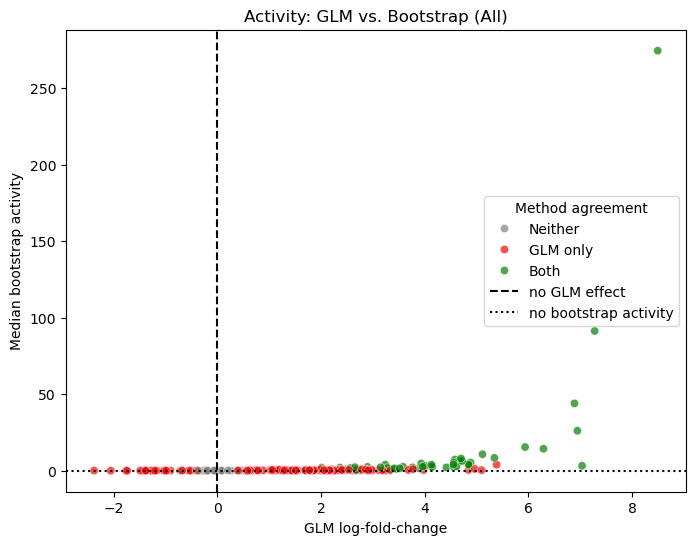

In [25]:
# define agreement categories
def category(row):
    if row.glm_is_active and row.is_active_all_reps: return "Both"
    if row.glm_is_active:                 return "GLM only"
    if row.is_active_all_reps:            return "Bootstrap only"
    return "Neither"

cmp["agreement"] = cmp.apply(category, axis=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=cmp,
    x="glm_max_activity_logFC",
    y="median_activity",
    hue="agreement",
    palette={"Both":"green","GLM only":"red","Bootstrap only":"blue","Neither":"gray"},
    alpha=0.7
)
ax.axvline(0, color="k", linestyle="--", label="no GLM effect")
ax.axhline(0, color="k", linestyle=":", label="no bootstrap activity")
plt.xlabel("GLM log-fold-change")
plt.ylabel("Median bootstrap activity")
plt.title("Activity: GLM vs. Bootstrap (All)")
plt.legend(title="Method agreement")
plt.show()
# plt.savefig("%s/plots/med_bootstrap_GLM_lFC.svg" % DATA_PATH)

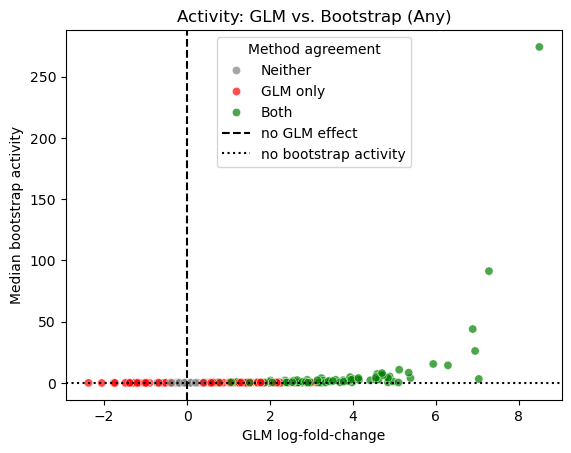

In [26]:
# define agreement categories
def category(row):
    if row.glm_is_active and row.is_active_any_reps: return "Both"
    if row.glm_is_active:                 return "GLM only"
    if row.is_active_any_reps:            return "Bootstrap only"
    return "Neither"

cmp["agreement"] = cmp.apply(category, axis=1)

sns.scatterplot(
    data=cmp,
    x="glm_max_activity_logFC",
    y="median_activity",
    hue="agreement",
    palette={"Both":"green","GLM only":"red","Bootstrap only":"blue","Neither":"gray"},
    alpha=0.7
)
plt.axvline(0, color="k", linestyle="--", label="no GLM effect")
plt.axhline(0, color="k", linestyle=":", label="no bootstrap activity")
plt.xlabel("GLM log-fold-change")
plt.ylabel("Median bootstrap activity")
plt.title("Activity: GLM vs. Bootstrap (Any)")
plt.legend(title="Method agreement")
plt.show()

## MWU

In [27]:
runner = scm.HypothesisTester("mwu", alternative="two-sided")  # can override defaults here
mwu_res_ct = runner.run(hs_all_ct, shendure, client=client)
mwu_res_cre = runner.run(hs_all_cre, shendure, client=client)

mwu_ct_df = mwu_res_ct.to_dataframe()
mwu_cre_df = mwu_res_cre.to_dataframe()

In [28]:
mwu_res_ct.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,ref_mean,comp_mean,test_type,bh_p
0,Gata4_chr14_5742,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,29860.0,3.046066e-40,22.203708,False,0.015162,0.548687,mwu,1.373568e-39
1,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,129545.0,3.996802e-01,0.743267,False,0.015162,0.008702,mwu,4.706696e-01
2,pgk1P,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,428234.0,4.697581e-230,560.451445,False,0.015162,14.092012,mwu,5.590892e-229
3,Foxa2_chr2_13840,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,38164.0,1.549167e-08,4.543907,False,0.015162,0.104333,mwu,3.981222e-08
4,Map1b_chr13_9447,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,49569.0,1.356719e-44,18.881284,False,0.015162,0.465089,mwu,6.354695e-44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Lama1_chr17_7814,reference,reference,reference,emvar_screen,6107647.5,2.491950e-18,2.060162,False,0.066704,0.148023,mwu,8.223434e-18
1448,Tgfbi_chr13_5735,reference,reference,reference,emvar_screen,5634524.0,1.960009e-02,0.621409,False,0.066704,0.037665,mwu,3.144677e-02
1449,Igfbp4_chr11_16738,reference,reference,reference,emvar_screen,2941214.0,1.325202e-03,1.759769,False,0.066704,0.124982,mwu,2.486037e-03
1450,Tgfbi_chr13_5701,reference,reference,reference,emvar_screen,2100560.0,8.982076e-02,0.559601,False,0.066704,0.032924,mwu,1.257664e-01


### compare to boot

In [29]:
mwu_ct_df_merge = pd.merge(mwu_ct_df, counts_groupby_cre_agg[['cre_id','cell_type','Mean','Mean_Norm']], left_on=['comparison_CRE', 'comparison_cell_type'], right_on = ["cre_id", "cell_type"], how='inner')
mwu_ct_df_merge

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,ref_mean,comp_mean,test_type,bh_p,cre_id,cell_type,Mean,Mean_Norm
0,Gata4_chr14_5742,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,29860.0,3.046066e-40,22.203708,False,0.015162,0.548687,mwu,1.373568e-39,Gata4_chr14_5742,Cardiomyocytes,1.018519,0.854951
1,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,129545.0,3.996802e-01,0.743267,False,0.015162,0.008702,mwu,4.706696e-01,Lamc1_chr1_12152,Cardiomyocytes,0.015625,0.012398
2,pgk1P,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,428234.0,4.697581e-230,560.451445,False,0.015162,14.092012,mwu,5.590892e-229,pgk1P,Cardiomyocytes,44.027027,74.399625
3,Foxa2_chr2_13840,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,38164.0,1.549167e-08,4.543907,False,0.015162,0.104333,mwu,3.981222e-08,Foxa2_chr2_13840,Cardiomyocytes,0.164706,0.204896
4,Map1b_chr13_9447,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,49569.0,1.356719e-44,18.881284,False,0.015162,0.465089,mwu,6.354695e-44,Map1b_chr13_9447,Cardiomyocytes,1.230769,1.074173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Lama1_chr17_7814,reference,reference,reference,emvar_screen,6107647.5,2.491950e-18,2.060162,False,0.066704,0.148023,mwu,8.223434e-18,Lama1_chr17_7814,reference,0.351588,0.212829
1448,Tgfbi_chr13_5735,reference,reference,reference,emvar_screen,5634524.0,1.960009e-02,0.621409,False,0.066704,0.037665,mwu,3.144677e-02,Tgfbi_chr13_5735,reference,0.059459,0.040890
1449,Igfbp4_chr11_16738,reference,reference,reference,emvar_screen,2941214.0,1.325202e-03,1.759769,False,0.066704,0.124982,mwu,2.486037e-03,Igfbp4_chr11_16738,reference,0.346491,0.200838
1450,Tgfbi_chr13_5701,reference,reference,reference,emvar_screen,2100560.0,8.982076e-02,0.559601,False,0.066704,0.032924,mwu,1.257664e-01,Tgfbi_chr13_5701,reference,0.049133,0.042656


In [30]:
mwu_ct_df_summary = mwu_ct_df_merge.loc[
    mwu_ct_df_merge.groupby("comparison_CRE")["Mean_Norm"].idxmax()
][["comparison_CRE", "test_statistic", "bh_p", "fold_change", "cell_type"]].rename(columns={
    "fold_change": "mwu_max_activity_fold_change",
    "bh_p": "mwu_activity_adj_p"
})

mwu_ct_df_summary["mwu_is_active"] = mwu_ct_df_summary["mwu_activity_adj_p"] < 0.05
mwu_ct_df_summary

,comparison_CRE,test_statistic,mwu_activity_adj_p,mwu_max_activity_fold_change,cell_type,mwu_is_active
378,Bend5_chr4_8168,824484.0,8.023366e-01,1.164341,ExEndodermParietal,False
1431,Bend5_chr4_8170,3686795.5,1.306684e-02,0.804086,reference,True
842,Bend5_chr4_8172,1531537.5,6.745966e-01,1.227146,Mesoderm,False
295,Bend5_chr4_8174,2661243.5,5.587245e-112,10.740751,ExEndodermParietal,True
47,Bend5_chr4_8175,41250.0,4.953058e-85,41.723400,Cardiomyocytes,True
...,...,...,...,...,...,...
1006,Txndc12_chr4_7975,2421513.0,8.023366e-01,1.089287,NeuroectodermBrain,False
1284,Txndc12_chr4_7978,11904455.5,0.000000e+00,13.589598,reference,True
101,eef1aP,7330725.0,0.000000e+00,1782.404208,EpiblastPrimitiveStreak,True
82,pgk1P,13724239.0,0.000000e+00,743.023306,EpiblastPrimitiveStreak,True


In [31]:
cmp = pd.merge(mwu_ct_df_summary, boot_act_grouped, left_on=['comparison_CRE'], right_on = ["cre_id"], how='inner')
cmp

,comparison_CRE,test_statistic,mwu_activity_adj_p,mwu_max_activity_fold_change,cell_type,mwu_is_active,median_activity,n_active_reps,is_active_all_reps,is_active_any_reps
0,Bend5_chr4_8168,824484.0,8.023366e-01,1.164341,ExEndodermParietal,False,0.103821,0,False,False
1,Bend5_chr4_8170,3686795.5,1.306684e-02,0.804086,reference,True,0.213704,0,False,False
2,Bend5_chr4_8172,1531537.5,6.745966e-01,1.227146,Mesoderm,False,0.074646,0,False,False
3,Bend5_chr4_8174,2661243.5,5.587245e-112,10.740751,ExEndodermParietal,True,0.824319,2,False,True
4,Bend5_chr4_8175,41250.0,4.953058e-85,41.723400,Cardiomyocytes,True,2.600635,3,True,True
...,...,...,...,...,...,...,...,...,...,...
202,Txndc12_chr4_7975,2421513.0,8.023366e-01,1.089287,NeuroectodermBrain,False,0.166358,0,False,False
203,Txndc12_chr4_7978,11904455.5,0.000000e+00,13.589598,reference,True,2.281744,3,True,True
204,eef1aP,7330725.0,0.000000e+00,1782.404208,EpiblastPrimitiveStreak,True,274.322946,3,True,True
205,pgk1P,13724239.0,0.000000e+00,743.023306,EpiblastPrimitiveStreak,True,91.282629,3,True,True


In [32]:
ct = pd.crosstab(
    cmp["mwu_is_active"],
    cmp["is_active_all_reps"],
    rownames=["MWU active"],
    colnames=["Bootstrap active"]
)
ct

Bootstrap active,False,True
MWU active,,
False,45,0
True,113,49


In [33]:
agree = (cmp["mwu_is_active"] == cmp["is_active_all_reps"]).mean()
print(f"Concordance = {agree:.1%}")

Concordance = 45.4%


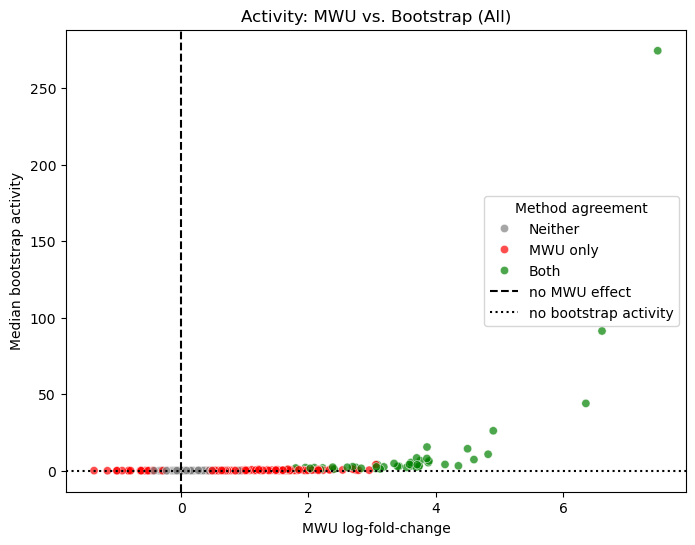

In [34]:
cmp['mwu_max_activity_logFC'] = np.log(cmp['mwu_max_activity_fold_change'])

# define agreement categories
def category(row):
    if row.mwu_is_active and row.is_active_all_reps: return "Both"
    if row.mwu_is_active:                 return "MWU only"
    if row.is_active_all_reps:            return "Bootstrap only"
    return "Neither"

cmp["agreement"] = cmp.apply(category, axis=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=cmp,
    x="mwu_max_activity_logFC",
    y="median_activity",
    hue="agreement",
    palette={"Both":"green","MWU only":"red","Bootstrap only":"blue","Neither":"gray"},
    alpha=0.7
)
ax.axvline(0, color="k", linestyle="--", label="no MWU effect")
ax.axhline(0, color="k", linestyle=":", label="no bootstrap activity")
plt.xlabel("MWU log-fold-change")
plt.ylabel("Median bootstrap activity")
plt.title("Activity: MWU vs. Bootstrap (All)")
plt.legend(title="Method agreement")
plt.show()
# plt.savefig("%s/plots/med_bootstrap_GLM_lFC.svg" % DATA_PATH)

# MWU vs Wald

In [35]:
mwu_ct_df
mwu_ct_df["mwu_is_active"] = mwu_ct_df["bh_p"] < 0.05
mwu_ct_df

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,ref_mean,comp_mean,test_type,bh_p,mwu_is_active
0,Gata4_chr14_5742,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,29860.0,3.046066e-40,22.203708,False,0.015162,0.548687,mwu,1.373568e-39,True
1,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,129545.0,3.996802e-01,0.743267,False,0.015162,0.008702,mwu,4.706696e-01,False
2,pgk1P,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,428234.0,4.697581e-230,560.451445,False,0.015162,14.092012,mwu,5.590892e-229,True
3,Foxa2_chr2_13840,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,38164.0,1.549167e-08,4.543907,False,0.015162,0.104333,mwu,3.981222e-08,True
4,Map1b_chr13_9447,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,49569.0,1.356719e-44,18.881284,False,0.015162,0.465089,mwu,6.354695e-44,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Lama1_chr17_7814,reference,reference,reference,emvar_screen,6107647.5,2.491950e-18,2.060162,False,0.066704,0.148023,mwu,8.223434e-18,True
1448,Tgfbi_chr13_5735,reference,reference,reference,emvar_screen,5634524.0,1.960009e-02,0.621409,False,0.066704,0.037665,mwu,3.144677e-02,True
1449,Igfbp4_chr11_16738,reference,reference,reference,emvar_screen,2941214.0,1.325202e-03,1.759769,False,0.066704,0.124982,mwu,2.486037e-03,True
1450,Tgfbi_chr13_5701,reference,reference,reference,emvar_screen,2100560.0,8.982076e-02,0.559601,False,0.066704,0.032924,mwu,1.257664e-01,False


In [36]:
wald_ct_df
wald_ct_df["wald_is_active"] = wald_ct_df["bh_p"] < 0.05
wald_ct_df

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,wald_is_active
0,Gata4_chr14_5742,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,11.844121,2.308257e-32,23.256896,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,7.115902e-32,True
1,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,-3.257119,1.125491e-03,0.354268,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,1.776319e-03,True
2,pgk1P,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,72.631512,2.225074e-308,980.591944,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,2.884649e-307,True
3,Foxa2_chr2_13840,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,4.152853,3.283563e-05,3.719022,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,5.563283e-05,True
4,Map1b_chr13_9447,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,31.558560,1.368294e-218,27.962383,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,1.351539e-217,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Lama1_chr17_7814,reference,reference,reference,emvar_screen,22.911439,3.573406e-116,2.129951,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,2.117790e-115,True
1448,Tgfbi_chr13_5735,reference,reference,reference,emvar_screen,-7.800293,6.176374e-15,0.360091,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,1.388250e-14,True
1449,Igfbp4_chr11_16738,reference,reference,reference,emvar_screen,13.824114,1.823430e-43,2.099714,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,6.379809e-43,True
1450,Tgfbi_chr13_5701,reference,reference,reference,emvar_screen,-4.685736,2.789561e-06,0.297607,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,4.888404e-06,True


In [37]:
cmp = pd.merge(mwu_ct_df, wald_ct_df, left_on=['comparison_CRE', 'comparison_cell_type'], right_on = ['comparison_CRE', 'comparison_cell_type'], how='inner', suffixes=['_mwu','_wald'])
cmp

,comparison_CRE,comparison_cell_type,reference_CRE_mwu,reference_cell_type_mwu,meta_mwu,test_statistic_mwu,p_value_mwu,fold_change_mwu,flattened_mwu,ref_mean,...,reference_cell_type_wald,meta_wald,test_statistic_wald,p_value_wald,fold_change_wald,flattened_wald,wald_debug,test_type_wald,bh_p_wald,wald_is_active
0,Gata4_chr14_5742,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,29860.0,3.046066e-40,22.203708,False,0.015162,...,Cardiomyocytes,emvar_screen,11.844121,2.308257e-32,23.256896,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,7.115902e-32,True
1,Lamc1_chr1_12152,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,129545.0,3.996802e-01,0.743267,False,0.015162,...,Cardiomyocytes,emvar_screen,-3.257119,1.125491e-03,0.354268,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,1.776319e-03,True
2,pgk1P,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,428234.0,4.697581e-230,560.451445,False,0.015162,...,Cardiomyocytes,emvar_screen,72.631512,2.225074e-308,980.591944,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,2.884649e-307,True
3,Foxa2_chr2_13840,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,38164.0,1.549167e-08,4.543907,False,0.015162,...,Cardiomyocytes,emvar_screen,4.152853,3.283563e-05,3.719022,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,5.563283e-05,True
4,Map1b_chr13_9447,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,49569.0,1.356719e-44,18.881284,False,0.015162,...,Cardiomyocytes,emvar_screen,31.558560,1.368294e-218,27.962383,False,"opg: Jmin=9.62e-02,Jmax=3.30e+03,condJ=3.43e+0...",wald,1.351539e-217,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1447,Lama1_chr17_7814,reference,reference,reference,emvar_screen,6107647.5,2.491950e-18,2.060162,False,0.066704,...,reference,emvar_screen,22.911439,3.573406e-116,2.129951,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,2.117790e-115,True
1448,Tgfbi_chr13_5735,reference,reference,reference,emvar_screen,5634524.0,1.960009e-02,0.621409,False,0.066704,...,reference,emvar_screen,-7.800293,6.176374e-15,0.360091,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,1.388250e-14,True
1449,Igfbp4_chr11_16738,reference,reference,reference,emvar_screen,2941214.0,1.325202e-03,1.759769,False,0.066704,...,reference,emvar_screen,13.824114,1.823430e-43,2.099714,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,6.379809e-43,True
1450,Tgfbi_chr13_5701,reference,reference,reference,emvar_screen,2100560.0,8.982076e-02,0.559601,False,0.066704,...,reference,emvar_screen,-4.685736,2.789561e-06,0.297607,False,"opg: Jmin=5.60e-02,Jmax=1.11e+05,condJ=1.99e+0...",wald,4.888404e-06,True


In [38]:
ct = pd.crosstab(
    cmp["mwu_is_active"],
    cmp["wald_is_active"],
    rownames=["MWU active"],
    colnames=["Wald active"]
)
ct

Wald active,False,True
MWU active,,
False,353,162
True,37,900


In [39]:
agree = (cmp["mwu_is_active"] == cmp["wald_is_active"]).mean()
print(f"Concordance = {agree:.1%}")

Concordance = 86.3%


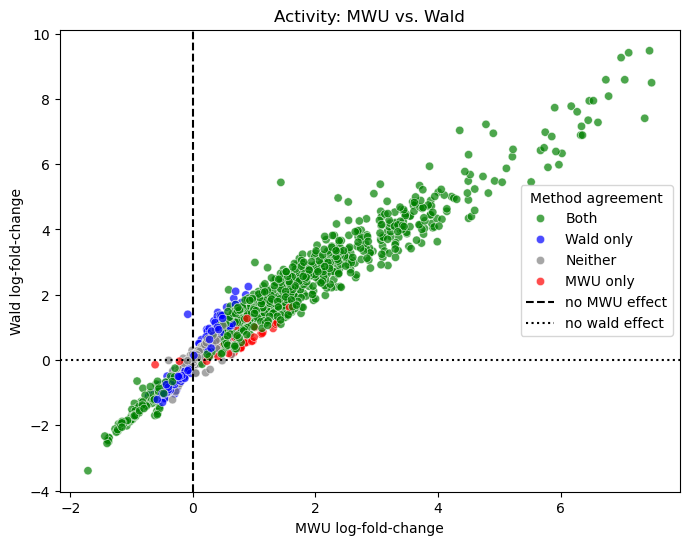

In [40]:
cmp['logFC_mwu'] = np.log(cmp['fold_change_mwu'])
cmp['logFC_wald'] = np.log(cmp['fold_change_wald'])

# define agreement categories
def category(row):
    if row.mwu_is_active and row.wald_is_active: return "Both"
    if row.mwu_is_active:                 return "MWU only"
    if row.wald_is_active:            return "Wald only"
    return "Neither"

cmp["agreement"] = cmp.apply(category, axis=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=cmp,
    x="logFC_mwu",
    y="logFC_wald",
    hue="agreement",
    palette={"Both":"green","MWU only":"red","Wald only":"blue","Neither":"gray"},
    alpha=0.7
)
ax.axvline(0, color="k", linestyle="--", label="no MWU effect")
ax.axhline(0, color="k", linestyle=":", label="no wald effect")
plt.xlabel("MWU log-fold-change")
plt.ylabel("Wald log-fold-change")
plt.title("Activity: MWU vs. Wald")
plt.legend(title="Method agreement")
plt.show()
# plt.savefig("%s/plots/med_bootstrap_GLM_lFC.svg" % DATA_PATH)

# Test boot

In [27]:
hs_boot = scm.make_bootstrap_activity_hypotheses(
    counts=shendure,
    comparison_cres="all",           # or a list of CREs
    controls="reference",            # or ["minP","noP"] if you kept them separate
    meta="bootstrap_activity"
)

In [28]:
rep_to_biol = {"A1": "A", "A2": "A", "B1": "B", "B2": "B", "2B1":"2B", "2B2":"2B"}

runner = scm.HypothesisTester(
    "bootstrap_activity",
    n_bootstraps=10_000, # default 10K
    rep_to_biol=rep_to_biol, # optional
)
res_boot = runner.run(hs_boot, shendure, client)
res_boot.to_dataframe()

KeyboardInterrupt: 

In [9]:
rb = res_boot.to_dataframe()
rb.set


In [6]:
DATA_PATH = '/gpfs/gibbs/pi/reilly/tabula_data/shendure'
glm_activity= pd.read_csv('%s/GLM_Wald/GLM_Wald_activity_summary_7212025.csv' % '/gpfs/gibbs/pi/reilly/tabula_data/shendure', index_col=0)


boot_activity = pd.read_csv("%s/empirical_pvalues/empirical_pvals_activity_20250519.tsv" % DATA_PATH, sep="\t")

# based on shendure:
ACTIVITY_PVAL_THRESH = 0.1
# Drop NAs first just in case
boot_activity = boot_activity.dropna(subset=["q50_bootstrap_max_exp_norm", "empirical_bootstrap_p_val_vs_noP_minP_BH_corr"])

boot_activity['cre_id'] = (boot_activity['cre_id']
                    .replace({'minP': 'Intercept (minP/noP)', 'noP': 'Intercept (minP/noP)'}))

# Activity summary
boot_act_grouped = boot_activity.groupby("cre_id").agg(
    median_activity=("q50_bootstrap_max_exp_norm", "median"),
    n_active_reps=("empirical_bootstrap_p_val_vs_noP_minP_BH_corr", lambda x: (x < ACTIVITY_PVAL_THRESH).sum())
)

# Flags
boot_act_grouped["is_active_all_reps"] = boot_act_grouped["n_active_reps"] == 3
boot_act_grouped["is_active_any_reps"] = boot_act_grouped["n_active_reps"] >=1

In [13]:
boot_merge = boot_act_grouped.merge(rb, left_index=True, right_on='comparison_CRE')

Pearson r = 0.996 (p = 5.22e-214)
Spearman ρ = 0.947 (p = 9.90e-103)


Text(0, 0.5, 'new bootstrap')

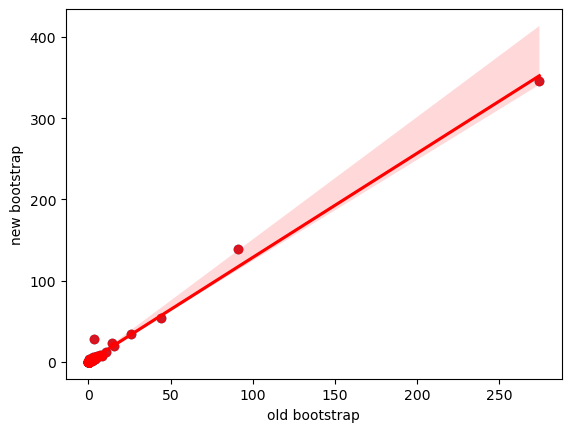

In [18]:
pearson_r, pearson_p = stats.pearsonr(boot_merge.median_activity,  boot_merge.test_statistic)
spearman_r, spearman_p = stats.spearmanr(boot_merge.median_activity,  boot_merge.test_statistic)
print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})")
plt.scatter(x=boot_merge.median_activity, y = boot_merge.test_statistic)
sns.regplot(
    data=boot_merge,
    x='median_activity',
    y='test_statistic',
    scatter=True,
    color='red',
    label=f'Fit: y={pearson_r:.2f}·x'
)

plt.xlabel('old bootstrap')
plt.ylabel('new bootstrap')

# Plotting

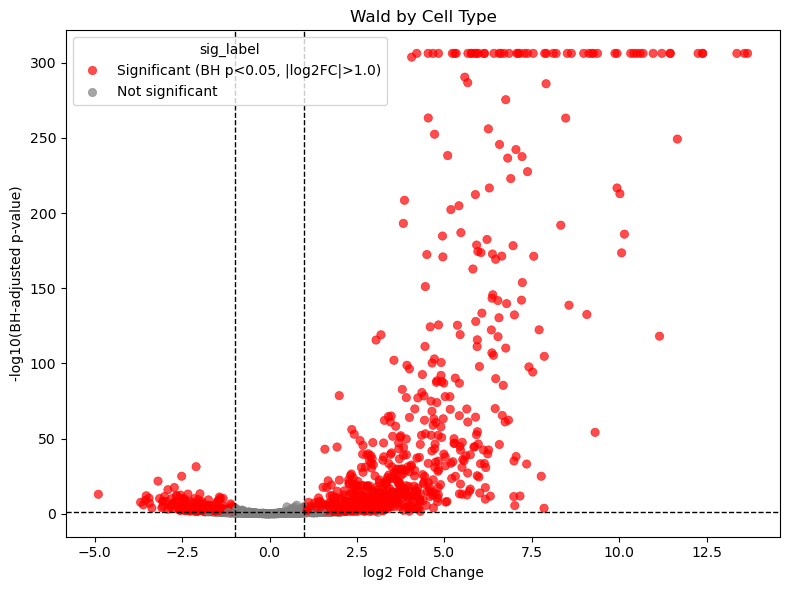

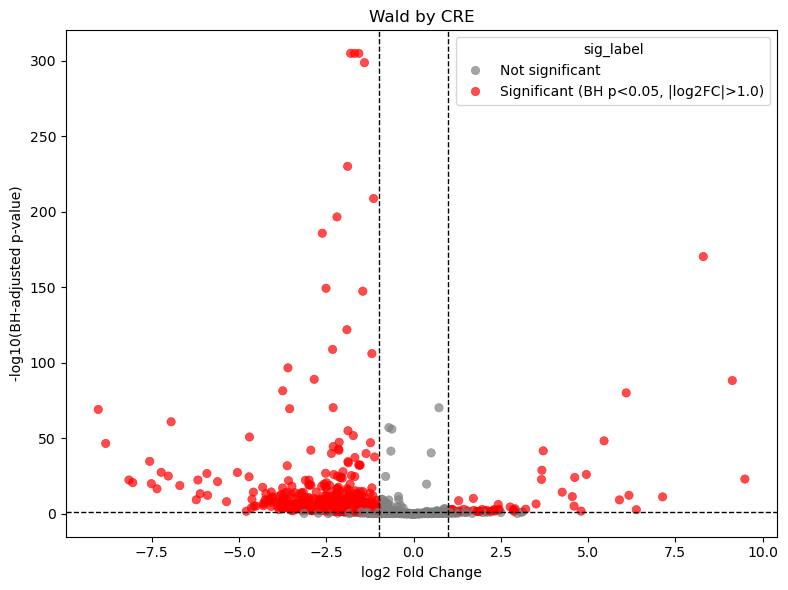

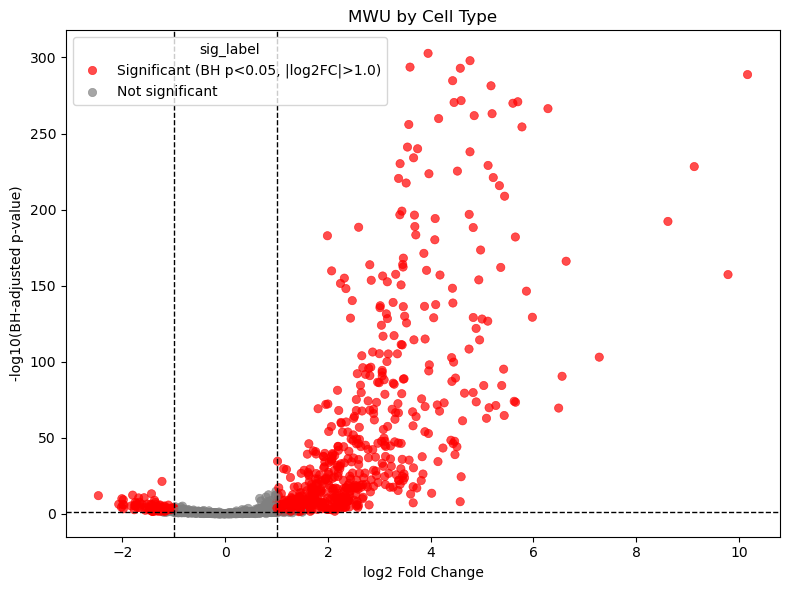

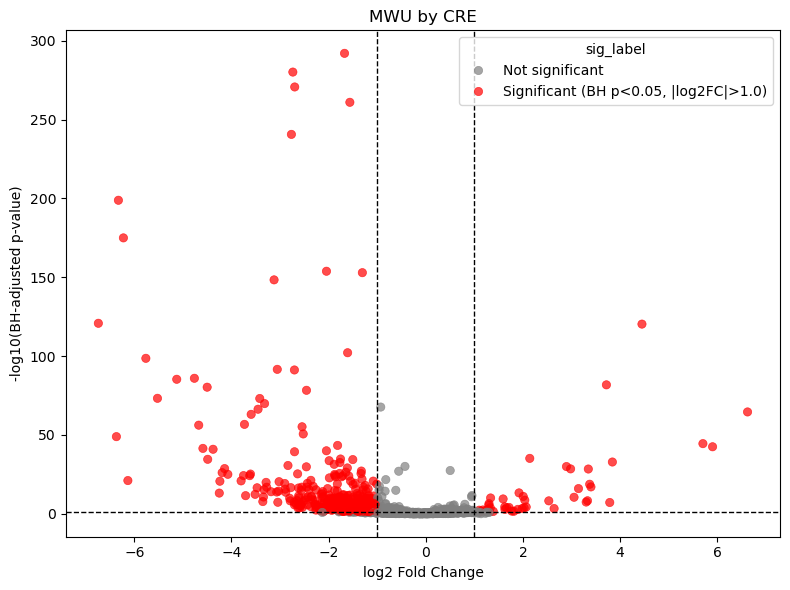

In [14]:
scm.volcano(wald_by_ct, title="Wald by Cell Type")
scm.volcano(wald_by_cre, title = 'Wald by CRE')
scm.volcano(mwu_res_ct, title = 'MWU by Cell Type')
scm.volcano(mwu_res_cre, title = 'MWU by CRE')